# 1.- (Cadena de MARKOV) “Campaña Publicitaria”

Supongamos que existen únicamente tres tipos de bebidas de cola los cuales de notaremos con la marca A (Coca Cola) la marca B (PEPSI) y la marca C (Del Valle) se ha observado a los consumidores y cuando ellos han pedido un refresco de cola se les ha preguntado cuál de ellos habían consumido en su última compra, los resultados de este estudio nos permiten afirmar que un 60 por ciento de aquellos que en su última compra eligieron la marca A han vuelto a comprar esta marca, un 30 de ellos ahora se encuentra consumiendo un refresco de la marca B y un 10 de ellos está consumiendo un refresco de la marca C, de aquellas personas que en su última compra escogieron la marca B un 50 por ciento de ellos sigue consumiendo esa marca, un 30 por ciento de ellos ahora consume un refresco de la marca A y un 20 por ciento de ellos consume un refresco de la marca C, finalmente de aquellos que en su última compra consumieron la marca C un 30 por ciento de ellos sigue prefiriendo esta marca, un 40 por ciento de ellos ahora se encuentra consumiendo un refresco de la marca A y un 30 por ciento de ellos consume un refresco de la marca B.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
m1 = np.matrix([[0.6, 0.3, 0.1],[0.3, 0.5, 0.2],[0.4, 0.3 , 0.3]])

m1

matrix([[0.6, 0.3, 0.1],
        [0.3, 0.5, 0.2],
        [0.4, 0.3, 0.3]])

In [19]:
m_aux = np.matrix([[], [], []])
m_aux_anterior = np.matrix([[], [], []])

In [20]:
#DETECTAR MATRIZ ESTABLE
for i in range(1000):
    if i == 0:
        m_aux = np.dot(m1, m1)
        print(m_aux)
        print("1-------------", i + 1)
    else:
        y = i + 1
        m_aux_anterior = m_aux
        m_aux = np.dot(m_aux, m1)
        print(m_aux)
        if (np.array_equal(m_aux, m_aux_anterior)):
            break
        print(y, "-------", i + 1)
print()
print("La matriz estable es:\n", np.round(m_aux, 4))

[[0.49 0.36 0.15]
 [0.41 0.4  0.19]
 [0.45 0.36 0.19]]
1------------- 1
[[0.462 0.372 0.166]
 [0.442 0.38  0.178]
 [0.454 0.372 0.174]]
2 ------- 2
[[0.4552 0.3744 0.1704]
 [0.4504 0.376  0.1736]
 [0.4536 0.3744 0.172 ]]
3 ------- 3
[[0.4536  0.37488 0.17152]
 [0.45248 0.3752  0.17232]
 [0.45328 0.37488 0.17184]]
4 ------- 4
[[0.453232 0.374976 0.171792]
 [0.452976 0.37504  0.171984]
 [0.453168 0.374976 0.171856]]
5 ------- 5
[[0.4531488 0.3749952 0.171856 ]
 [0.4530912 0.375008  0.1719008]
 [0.453136  0.3749952 0.1718688]]
6 ------- 6
[[0.45313024 0.37499904 0.17187072]
 [0.45311744 0.3750016  0.17188096]
 [0.45312768 0.37499904 0.17187328]]
7 ------- 7
[[0.45312614 0.37499981 0.17187405]
 [0.45312333 0.37500032 0.17187635]
 [0.45312563 0.37499981 0.17187456]]
8 ------- 8
[[0.45312525 0.37499996 0.17187479]
 [0.45312463 0.37500006 0.1718753 ]
 [0.45312515 0.37499996 0.17187489]]
9 ------- 9
[[0.45312505 0.37499999 0.17187495]
 [0.45312492 0.37500001 0.17187507]
 [0.45312503 0.37499999

A. Supongamos que hay una población de 1000 elementos, determinar las cantidades de población para cada estado con los siguientes datos de distribución inicial marca A=200, B=300 y C=500.

In [21]:
poblacion_inicial = np.matrix([200, 300, 500])

poblacion_inicial

matrix([[200, 300, 500]])

In [22]:
print("Poblacion inicial----V0")
for z in range(20):
    if z == 0:
        poblacion_inicial = np.dot(poblacion_inicial, m1)
        poblacion_inicial = np.round(poblacion_inicial, 2)
        print("Poblacion inicial")
        print("-------------", z+1)
    else:
        poblacion_anterior = poblacion_inicial
        poblacion_inicial = np.dot(poblacion_inicial, m1)
        poblacion_inicial = np.round(poblacion_inicial, 2)
        if (np.array_equal(poblacion_inicial, poblacion_anterior)):
            print("Poblacion inicial y anterior iguales")
            print("*** numero de iteraciones", str(z), "***")
            poblacion_inicial = np.round(poblacion_inicial, 0)
            poblacion_inicial = poblacion_inicial.astype(int)
            print("Poblacion final:\n", poblacion_inicial)
            print("N ---------", z+1)
            break
print(poblacion_inicial)
print("La poblacion se estabiliza en la iteracion", z+1)

Poblacion inicial----V0
Poblacion inicial
------------- 1
Poblacion inicial y anterior iguales
*** numero de iteraciones 6 ***
Poblacion final:
 [[453 375 172]]
N --------- 7
[[453 375 172]]
La poblacion se estabiliza en la iteracion 7


B. Tenemos un país con 50 millones de habitantes y el consumo promedio de refrescos por persona es de 1 litro a la semana, dado que la semana contiene 52 semanas, ¿cuánto será el consumo Anual en litros y cuantos de esos litros corresponden a cada compañía? Grafique este consumo anual por compañía.

In [23]:
habitantes = 50000000
consumo_promedio_de_refrescos_por_persona = 1
año = 52 #Semanas por año
consumo_anual_por_litros = habitantes * consumo_promedio_de_refrescos_por_persona * año
print("Consumo anual de refrescos en litros:", consumo_anual_por_litros)
consumo_coca_cola = consumo_anual_por_litros * (poblacion_inicial[0, 0] / np.sum(poblacion_inicial))
consumo_pepsi = consumo_anual_por_litros * (poblacion_inicial[0, 1] / np.sum(poblacion_inicial))
consumo_valle = consumo_anual_por_litros * (poblacion_inicial[0, 2] / np.sum(poblacion_inicial))
print("-----Consumo por marca-----")
print("Consumo anual de Coca-Cola en litros:", round(consumo_coca_cola, 0))
print("Consumo anual de Pepsi en litros:", round(consumo_pepsi, 0))
print("Consumo anual de Del Valle en litros:", round(consumo_valle, 0))

Consumo anual de refrescos en litros: 2600000000
-----Consumo por marca-----
Consumo anual de Coca-Cola en litros: 1177800000.0
Consumo anual de Pepsi en litros: 975000000.0
Consumo anual de Del Valle en litros: 447200000.0


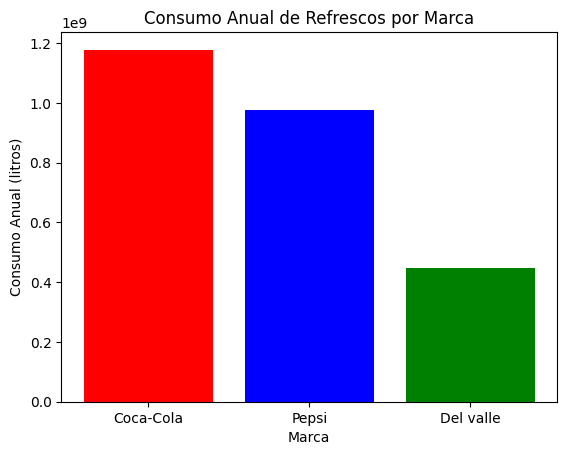

In [24]:
marcas = ['Coca-Cola', 'Pepsi', 'Del valle']
consumos = [consumo_coca_cola, consumo_pepsi, consumo_otros]
plt.bar(marcas, consumos, color=['red', 'blue', 'green'])
plt.title('Consumo Anual de Refrescos por Marca')
plt.xlabel('Marca')
plt.ylabel('Consumo Anual (litros)')
plt.show()

C. Cada litro vendido provee una utilidad 0.25 centavos de dólar. Ahora se decide que la marca C ha decidido hacer una campaña de mercadotecnia, esta campaña le asegura que retendrá un 10% más de clientes y se garantiza solo por 1 año, después del término de la

campaña lo más probable es que los consumidores regresen a sus hábitos de compra, para esta campaña se tendrán que invertir 20,000,000 de dólares. ¿Determine con evidencias si vale la pena implementar la campaña e invertir esos 20,000,000 de dólares?